**Modelo de predição Alta/Óbito por Covid-19 a partir de informações do paciente**

*Inicialização e carregamento de dados*

In [2]:
#Importa os pacotes a serem utilizados
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn import preprocessing
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import balanced_accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn import datasets, metrics

from sklearn import preprocessing
import category_encoders as ce

from sklearn.model_selection import GridSearchCV

import sys
if not sys.warnoptions:
    import warnings
    warnings.simplefilter("ignore")

**Considerando a classificação (target) da categoriazação de gravidade**

In [326]:
#Carrega novamente os dados
df_dados_gravidade = pd.read_csv('Banco_AM_LUCIAN.csv', sep=';')

*Define a nova categoria 'Gravidade'*

In [327]:
#Categorias de gravidade
#1 - Uso UTI ou VM = Grave
#2 - Caso contrário = Não Grave

In [328]:
index_exclusao_nan = df_dados_gravidade[ (pd.isna(df_dados_gravidade['VM'])) | (pd.isna(df_dados_gravidade['UTI'])) ].index
df_dados_gravidade = df_dados_gravidade.drop(index_exclusao_nan)

In [329]:
df_dados_gravidade['VM'].unique()

array([2., 1.])

In [330]:
df_dados_gravidade_reduzido = df_dados_gravidade 

In [331]:
df_dados_gravidade_reduzido

,IDADE,SEXO,RACA,ESCOL,GRUPO_CANCER,TIPO_TUMOR,PERIODO_PAND,TIPO_HOSP,VACINACAO,NOSOCOMIAL,...,NEUROLOGIC,ASMA,PNEUMOPATI,IMUNODEPRE,RENAL,OBESIDADE,UTI,SUPORT_VEN,VM,EVOLUCAO
1,64,1,2.0,2.0,2,1,1,1,NaN,NaN,...,2,2,2,2,2,2,2.0,1.0,2.0,2
2,54,1,2.0,4.0,14,2,1,1,NaN,NaN,...,2,2,2,1,2,2,2.0,1.0,2.0,2
3,33,2,2.0,3.0,7,1,1,1,NaN,2.0,...,2,2,2,2,2,2,2.0,1.0,2.0,1
6,56,1,1.0,3.0,9,1,1,1,NaN,2.0,...,2,2,2,2,2,2,2.0,2.0,2.0,2
7,81,2,2.0,1.0,8,1,1,1,NaN,2.0,...,2,2,2,2,2,2,2.0,1.0,2.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1222,76,2,1.0,NaN,7,1,4,1,NaN,NaN,...,2,2,2,2,2,2,2.0,1.0,2.0,2
1223,71,1,1.0,NaN,14,2,4,1,NaN,2.0,...,2,2,2,2,2,2,1.0,1.0,1.0,1
1224,68,1,1.0,NaN,14,2,4,1,2.0,2.0,...,2,2,2,2,2,2,2.0,1.0,2.0,2
1225,84,1,NaN,NaN,14,2,4,1,NaN,2.0,...,2,2,2,2,2,2,1.0,1.0,1.0,2


*Função que define a nova categoria*

In [332]:
#x['UTI'] == 1 -> Sim, uso de UTI ou x['VM'] == 1 -> Sim, uso de VM
#Então Grave
#Senão Não-Grave
def categoriza_gravidade(x):
    if ((x['EVOLUCAO'] == 2) or (x['EVOLUCAO'] == 3)) and ((x['UTI'] == 1) or (x['VM'] == 1)):
        return 3
    if (x['EVOLUCAO'] == 2) or (x['EVOLUCAO'] == 3):
        return 3
    if (x['UTI'] == 1) or (x['VM'] == 1): # or (x['EVOLUCAO'] == 2) or (x['EVOLUCAO'] == 3):
        return 1 #'Grave'
    else:
        return 2 #'Não Grave'
    
classes = ['Grave', 'Não Grave', 'Óbito'] #, 'Óbito pós gravidade']

In [333]:
y_gravidade = df_dados_gravidade_reduzido.apply(categoriza_gravidade, axis=1)

In [334]:
y_gravidade

1       3
2       3
3       2
6       3
7       3
       ..
1222    3
1223    1
1224    3
1225    3
1226    1
Length: 881, dtype: int64

In [335]:
df_dados_gravidade_reduzido['GRAVIDADE'] = y_gravidade

Elimina variáveis com menos de 60% de preenchimento

In [336]:
for c in df_dados_gravidade_reduzido.columns:
    percentual_nulos = len(df_dados_gravidade_reduzido[ df_dados_gravidade_reduzido[c].isna() ]) / len(df_dados_gravidade_reduzido)
    print(c, 1 - percentual_nulos)
    if (1 - percentual_nulos) <= 0.6:
        df_dados_gravidade_reduzido.drop(columns=[c], inplace = True)

IDADE 1.0
SEXO 1.0
RACA 0.8024971623155506
ESCOL 0.4370034052213394
GRUPO_CANCER 1.0
TIPO_TUMOR 1.0
PERIODO_PAND 1.0
TIPO_HOSP 1.0
VACINACAO 0.18161180476730987
NOSOCOMIAL 0.619750283768445
SINTOMA 1.0
FEBRE 0.7570942111237231
TOSSE 0.7934165720771851
GARGANTA 0.641316685584563
DISPNEIA 0.8331441543700341
DESC_RESP 0.7934165720771851
SATURACAO 0.7945516458569807
DIARREIA 0.6481271282633372
VOMITO 0.6606129398410896
DOR_ABD 0.40295119182746875
FADIGA 0.4290578887627696
PERD_OLFT 0.3881952326901249
PERD_PALA 0.3870601589103292
COMORB 1.0
CARDIOPATI 1.0
HEMATOLOGI 1.0
HEPATICA 1.0
DIABETES 1.0
NEUROLOGIC 1.0
ASMA 1.0
PNEUMOPATI 1.0
IMUNODEPRE 1.0
RENAL 1.0
OBESIDADE 1.0
UTI 1.0
SUPORT_VEN 1.0
VM 1.0
EVOLUCAO 1.0
GRAVIDADE 1.0


*Limpa o conjunto de treinamento das informações de saíde (EVOLUCAO, UTI, VM) e sintomas previamente selecionados para remoção*

In [337]:
df_dados_gravidade_reduzido.columns

Index(['IDADE', 'SEXO', 'RACA', 'GRUPO_CANCER', 'TIPO_TUMOR', 'PERIODO_PAND',
       'TIPO_HOSP', 'NOSOCOMIAL', 'SINTOMA', 'FEBRE', 'TOSSE', 'GARGANTA',
       'DISPNEIA', 'DESC_RESP', 'SATURACAO', 'DIARREIA', 'VOMITO', 'COMORB',
       'CARDIOPATI', 'HEMATOLOGI', 'HEPATICA', 'DIABETES', 'NEUROLOGIC',
       'ASMA', 'PNEUMOPATI', 'IMUNODEPRE', 'RENAL', 'OBESIDADE', 'UTI',
       'SUPORT_VEN', 'VM', 'EVOLUCAO', 'GRAVIDADE'],
      dtype='object')

In [338]:
#Exclui todos os dados de casos com evolução para óbito que não seja por Covid-19
df_dados_gravidade_reduzido = df_dados_gravidade_reduzido[df_dados_gravidade_reduzido['EVOLUCAO'] != 3]

In [339]:
#df_dados_gravidade_reduzido = df_dados_gravidade_reduzido.drop(['EVOLUCAO', 'UTI', 'SUPORT_VEN', 'VM', 'PNEUMOPATI', 'ASMA', 'RENAL', 'OBESIDADE', 'NEUROLOGIC', 'HEPATICA', 'HEMATOLOGI', 'FEBRE', 'TOSSE', 'DISPNEIA', 'DESC_RESP', 'SATURACAO', 'CARDIOPATI', 'DIABETES','IMUNODEPRE', 'TIPO_TUMOR', 'ESCOL', 'NOSOCOMIAL'], axis=1)
df_dados_gravidade_reduzido = df_dados_gravidade_reduzido.drop(['EVOLUCAO', 'UTI', 'SUPORT_VEN', 'VM', 'PNEUMOPATI', 'ASMA', 'RENAL', 'OBESIDADE', 'NEUROLOGIC', 'HEPATICA', 'HEMATOLOGI', 'TIPO_TUMOR', 'NOSOCOMIAL', 'GARGANTA', 'DIARREIA', 'VOMITO'], axis=1)

In [340]:
df_dados_gravidade_reduzido = df_dados_gravidade_reduzido.fillna(99)

In [341]:
df_dados_gravidade_reduzido.columns

Index(['IDADE', 'SEXO', 'RACA', 'GRUPO_CANCER', 'PERIODO_PAND', 'TIPO_HOSP',
       'SINTOMA', 'FEBRE', 'TOSSE', 'DISPNEIA', 'DESC_RESP', 'SATURACAO',
       'COMORB', 'CARDIOPATI', 'DIABETES', 'IMUNODEPRE', 'GRAVIDADE'],
      dtype='object')

In [342]:
df_dados_gravidade_reduzido

,IDADE,SEXO,RACA,GRUPO_CANCER,PERIODO_PAND,TIPO_HOSP,SINTOMA,FEBRE,TOSSE,DISPNEIA,DESC_RESP,SATURACAO,COMORB,CARDIOPATI,DIABETES,IMUNODEPRE,GRAVIDADE
1,64,1,2.0,2,1,1,5,1.0,1.0,1.0,1.0,1.0,8,2,2,2,3
2,54,1,2.0,14,1,1,3,99.0,1.0,1.0,1.0,99.0,2,2,2,1,3
3,33,2,2.0,7,1,1,2,99.0,99.0,1.0,99.0,1.0,8,2,2,2,2
6,56,1,1.0,9,1,1,2,2.0,1.0,2.0,1.0,2.0,8,2,2,2,3
7,81,2,2.0,8,1,1,4,1.0,2.0,1.0,1.0,1.0,8,2,2,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1222,76,2,1.0,7,4,1,3,1.0,2.0,1.0,2.0,1.0,8,2,2,2,3
1223,71,1,1.0,14,4,1,4,2.0,2.0,1.0,1.0,1.0,8,2,2,2,1
1224,68,1,1.0,14,4,1,3,2.0,2.0,1.0,1.0,1.0,8,2,2,2,3
1225,84,1,99.0,14,4,1,3,99.0,99.0,1.0,1.0,1.0,2,1,2,2,3


*Prepara o conjunto X e y para geração do modelo de aprendizagem de máquina*

In [343]:
y = df_dados_gravidade_reduzido['GRAVIDADE']
X = df_dados_gravidade_reduzido.drop('GRAVIDADE', axis=1)

<AxesSubplot:>

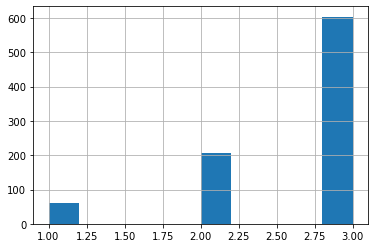

In [344]:
y.hist()

*Aplica o balanceamento do conjunto de treinamento pelo RandomUnderSampler*

In [345]:
from imblearn.under_sampling import RandomUnderSampler
#rus = RandomUnderSampler()
#X, y = rus.fit_resample(X, y)

<AxesSubplot:>

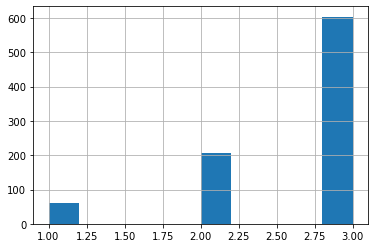

In [346]:
y.hist()

*Separa entre conjunto de treinamento e teste*

In [394]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)#, stratify=y)

In [395]:
#from sklearn.preprocessing import StandardScaler
#scaler = StandardScaler()
#X_train = scaler.fit_transform(X_train)
#X_test  = scaler.transform(X_test)

<AxesSubplot:>

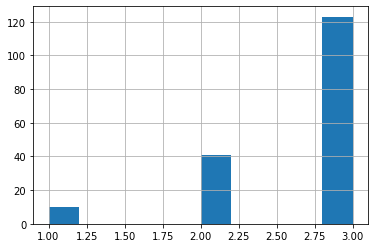

In [396]:
y_test.hist()

<AxesSubplot:>

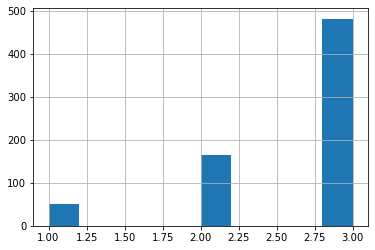

In [397]:
y_train.hist()

*Aplica o balanceamento do conjunto de treinamento pelo SMOTE*

In [398]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(k_neighbors=2)
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler()
#from imblearn.combine import SMOTEENN
#smote = SMOTEENN(random_state=0)
#from imblearn.combine import SMOTETomek
#rus = SMOTETomek(random_state=0)
smote = SMOTE(sampling_strategy = {1: 300, 2: 300})
rus = RandomUnderSampler(sampling_strategy = {3: 300})


In [399]:
X_train, y_train = smote.fit_resample(X_train, y_train)

In [400]:
X_train, y_train = rus.fit_resample(X_train, y_train)

<AxesSubplot:>

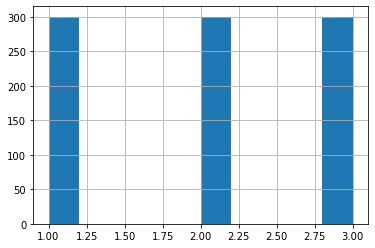

In [401]:
y_train.hist()

In [386]:
#Inicializa a classe RandomForest
rf = RandomForestClassifier()

#Elenca os hiperparâmetros a serem testados para a RandomForest
parameters = {
               'max_depth': [10], #(5, 10), 
               'n_estimators': [300], #[10, 100, 300],
               'random_state': [42], #[0, 42, 16],
               'criterion': ['gini', 'entropy'],
                'max_features': [None],
               # 'class_weight': [{1: 1000, 2: 10, 3: 1, 4: 10}]
}

clf = GridSearchCV(rf, parameters, cv = 2)

#Ajusta o melhor modelo (melhores parâmetros aos dados de treinamento)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

#Avalia a qualidade do modelo final
print(classification_report(y_test, y_pred,  target_names=classes)) #target_names=['Indiviual','Conjunto', 'Nenhum']))
accuracy_score(y_test, y_pred)

              precision    recall  f1-score   support

       Grave       0.29      0.20      0.24        10
   Não Grave       0.30      0.27      0.28        41
       Óbito       0.74      0.78      0.76       123

    accuracy                           0.63       174
   macro avg       0.44      0.42      0.43       174
weighted avg       0.61      0.63      0.62       174



0.6264367816091954

In [387]:
#Exibe os melhores hiperparâmetros encontrados
print(clf.best_params_)
best_rf = RandomForestClassifier()
best_rf.set_params(**clf.best_params_)

best_rf.fit(X_train, y_train)
y_pred = best_rf.predict(X_test)
print(classification_report(y_test, y_pred,  target_names=classes))
accuracy_score(y_test, y_pred)

{'criterion': 'gini', 'max_depth': 10, 'max_features': None, 'n_estimators': 300, 'random_state': 42}
              precision    recall  f1-score   support

       Grave       0.29      0.20      0.24        10
   Não Grave       0.30      0.27      0.28        41
       Óbito       0.74      0.78      0.76       123

    accuracy                           0.63       174
   macro avg       0.44      0.42      0.43       174
weighted avg       0.61      0.63      0.62       174



0.6264367816091954

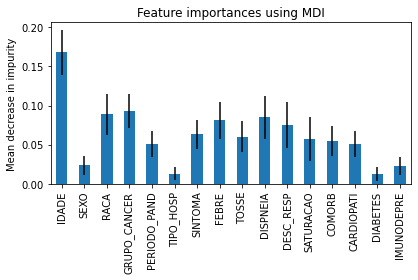

In [388]:
std = np.std([tree.feature_importances_ for tree in best_rf.estimators_], axis=0)

feature_names = [f"feature {i}" for i in range(X.shape[1])]
feature_names = X.columns
importances = best_rf.feature_importances_
forest_importances = pd.Series(importances, index=feature_names)

fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

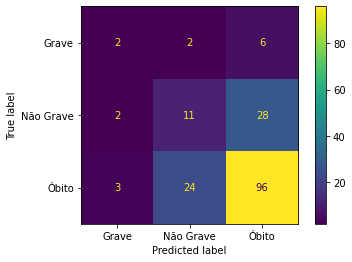

In [389]:
ConfusionMatrixDisplay.from_estimator(best_rf, X_test, y_test, display_labels= classes)

<AxesSubplot:>

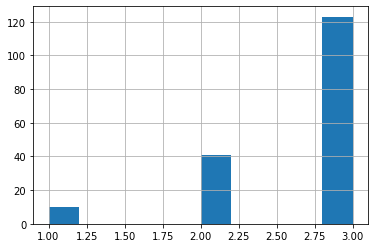

In [390]:
y_test.hist()

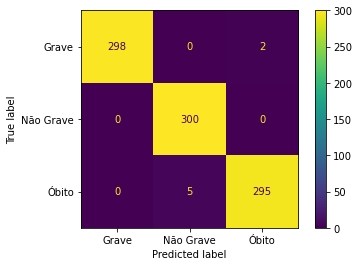

In [391]:
ConfusionMatrixDisplay.from_estimator(best_rf, X_train, y_train, display_labels= classes)

In [101]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import sklearn
import pandas as pd
import keras
from keras.models import Sequential
from keras.layers import Dense
import tensorflow as tf
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
from sklearn.preprocessing import MinMaxScaler

2024-08-17 11:08:27.807683: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-08-17 11:08:28.133362: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-08-17 11:08:28.133453: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-08-17 11:08:28.135927: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-08-17 11:08:28.291511: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-08-17 11:08:28.295212: I tensorflow/core/platform/cpu_feature_guard.cc:182] This Tens

In [121]:
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler()
X_scaled, y_scaled = rus.fit_resample(X, y)

In [122]:
scaler = MinMaxScaler()
scaler.fit(X_scaled)
t_df = scaler.transform(X_scaled)

In [123]:
X_train, X_test, y_train, y_test = train_test_split(t_df, y_scaled, test_size=0.25, random_state=0)

In [124]:
print('X_train:',np.shape(X_train))
print('y_train:',np.shape(y_train))
print('X_test:',np.shape(X_test))
print('y_test:',np.shape(y_test))

X_train: (309, 16)
y_train: (309,)
X_test: (103, 16)
y_test: (103,)


In [125]:
basic_model = Sequential()

In [126]:
basic_model.add(Dense(units=16, activation='relu', input_shape=(16,)))

In [127]:
basic_model.add(Dense(1, activation='sigmoid'))

In [128]:
adam = keras.optimizers.Adam(learning_rate=0.001)

In [129]:
basic_model.compile(loss='binary_crossentropy', optimizer=adam, metrics=["accuracy"])

In [130]:
basic_model.fit(X_train, y_train, epochs=100)

Epoch 1/100
10/10 [==============================] - 0s 1ms/step - loss: 0.4865 - accuracy: 0.3883
Epoch 2/100
10/10 [==============================] - 0s 2ms/step - loss: 0.2407 - accuracy: 0.4628
Epoch 3/100
10/10 [==============================] - 0s 3ms/step - loss: 0.0041 - accuracy: 0.4951
Epoch 4/100
10/10 [==============================] - 0s 2ms/step - loss: -0.2255 - accuracy: 0.4951
Epoch 5/100
10/10 [==============================] - 0s 3ms/step - loss: -0.4446 - accuracy: 0.4951
Epoch 6/100
10/10 [==============================] - 0s 2ms/step - loss: -0.6627 - accuracy: 0.4951
Epoch 7/100
10/10 [==============================] - 0s 4ms/step - loss: -0.8828 - accuracy: 0.4951
Epoch 8/100
10/10 [==============================] - 0s 2ms/step - loss: -1.1039 - accuracy: 0.4951
Epoch 9/100
10/10 [==============================] - 0s 2ms/step - loss: -1.3317 - accuracy: 0.4951
Epoch 10/100
10/10 [==============================] - 0s 3ms/step - loss: -1.5679 - accuracy: 0.4951
Ep

In [131]:
loss_and_metrics = basic_model.evaluate(X_test, y_test)
print(loss_and_metrics)
print('Loss = ',loss_and_metrics[0])
print('Accuracy = ',loss_and_metrics[1])

4/4 [==============================] - 0s 2ms/step - loss: -91.2787 - accuracy: 0.5146
[-91.2787094116211, 0.5145630836486816]
Loss =  -91.2787094116211
Accuracy =  0.5145630836486816


In [132]:
predicted = basic_model.predict(X_test)

4/4 [==============================] - 0s 1ms/step


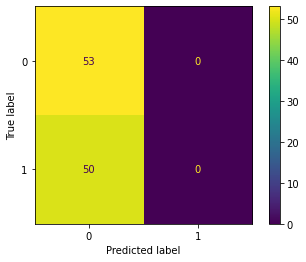

In [133]:
predicted = tf.squeeze(predicted)
predicted = np.array([1 if x >= 0.5 else 0 for x in predicted])
actual = np.array(y_test)
conf_mat = confusion_matrix(actual, predicted)
displ = ConfusionMatrixDisplay(confusion_matrix=conf_mat)
displ.plot()